## intent classification

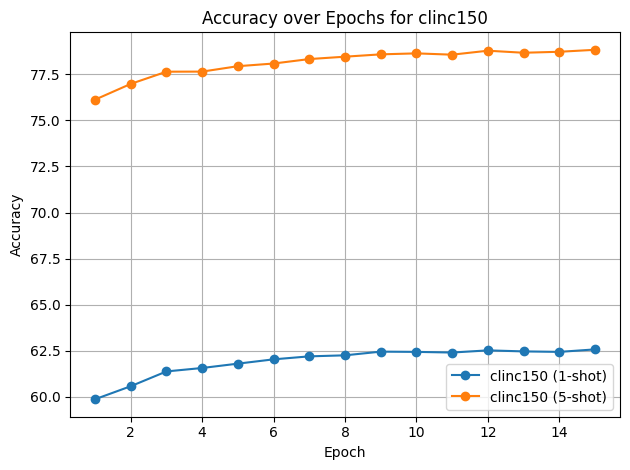

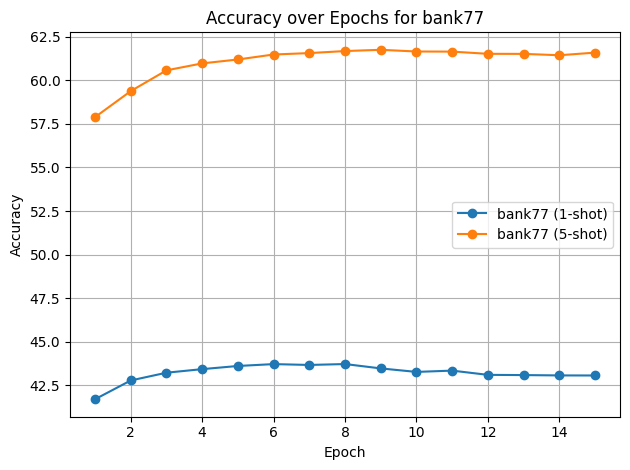

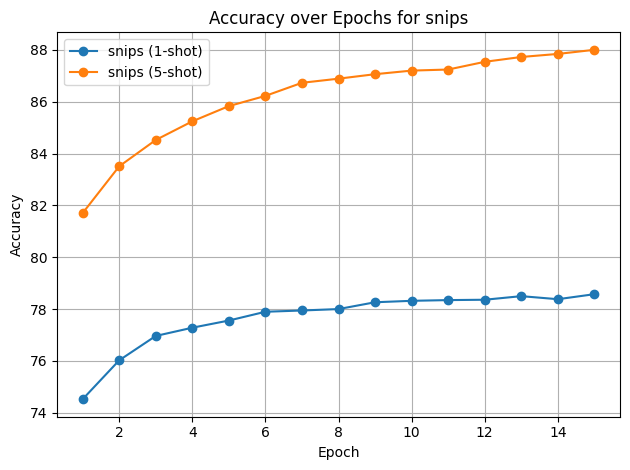

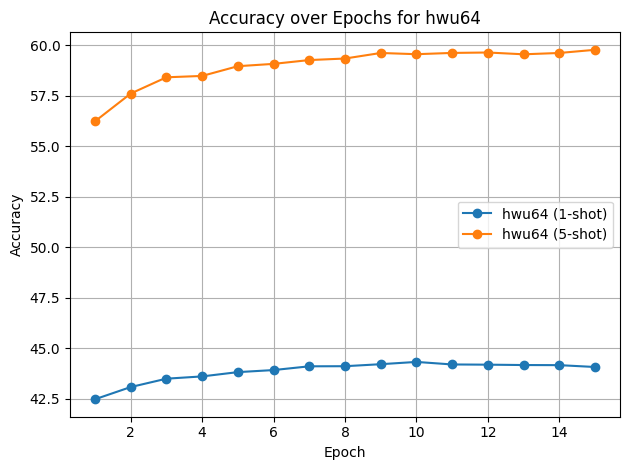

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# Путь к папке, где лежат результаты
base_path = "/home/coder/project/metrics_contrastive_baseline/intent_sim/contrastive_bertbasecontrastive.HardNeg.epoch15.bertbase.dse_training.tsv.lr3e-06.lrscale100.bs1024.tmp0.05.decay1.seed1.turn1"

# Список для хранения всех данных
data = []

# Проход по папкам с эпохами
for epoch in range(1, 16):
    file_path = os.path.join(base_path, str(epoch), "results.txt")
    if os.path.exists(file_path):
        with open(file_path, 'r') as file:
            lines = file.readlines()
            for line in lines:
                match = re.match(r"(\w+)\|([15])\|(\d+)\|average_embedding average_acc: ([\d.]+)", line.strip())
                if match:
                    dataset, shot, ep, acc = match.groups()
                    data.append({
                        "dataset": dataset,
                        "shot": int(shot),
                        "epoch": int(ep),
                        "accuracy": float(acc)
                    })

# Создание DataFrame
df = pd.DataFrame(data)

# Построение графиков по каждому датасету и уровню few-shot (1 или 5)
datasets = df['dataset'].unique()
shots = df['shot'].unique()

for dataset in datasets:
    plt.figure()
    for shot in shots:
        subset = df[(df['dataset'] == dataset) & (df['shot'] == shot)]
        plt.plot(subset['epoch'], subset['accuracy'], marker='o', label=f"{dataset} ({shot}-shot)")
    plt.title(f"Accuracy over Epochs for {dataset}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


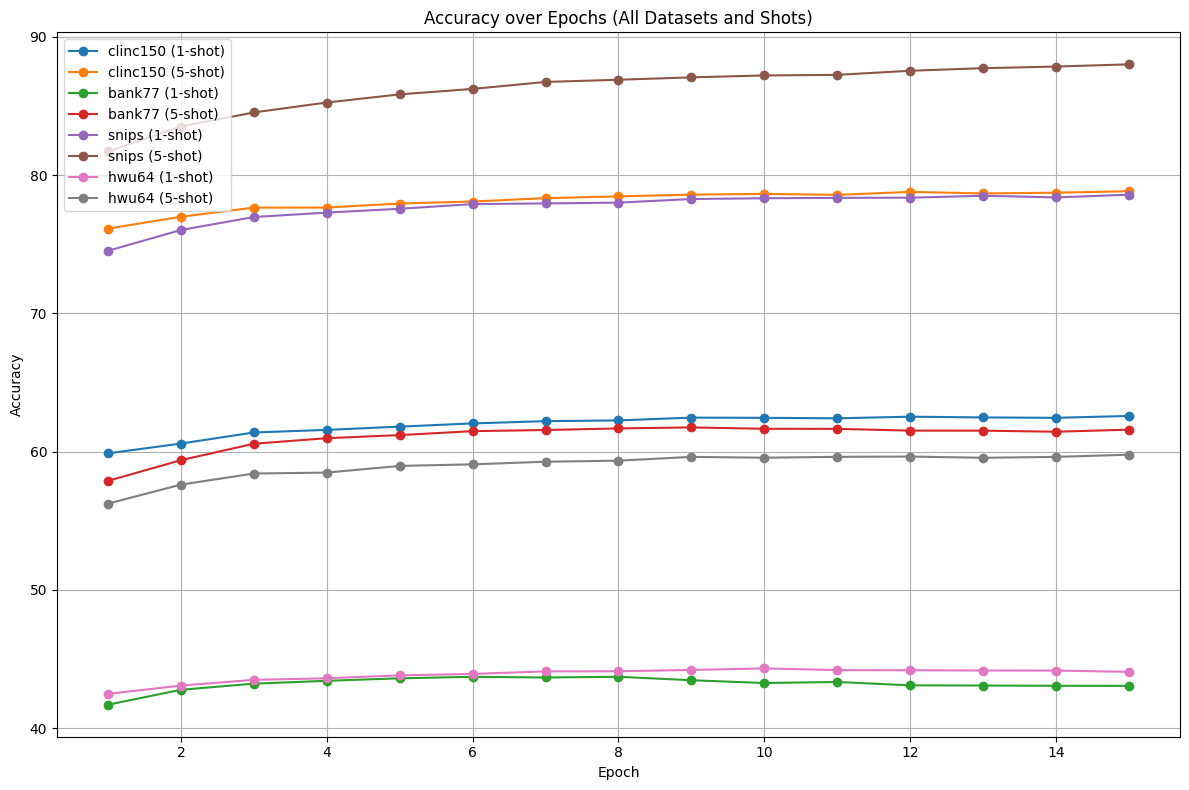

In [2]:
# Построение всех графиков на одном
plt.figure(figsize=(12, 8))

for dataset in datasets:
    for shot in shots:
        subset = df[(df['dataset'] == dataset) & (df['shot'] == shot)]
        if not subset.empty:
            label = f"{dataset} ({shot}-shot)"
            plt.plot(subset['epoch'], subset['accuracy'], marker='o', label=label)

plt.title("Accuracy over Epochs (All Datasets and Shots)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/home/coder/tmp/ipykernel_30868/925280293.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab10', len(set([d["dataset"] for d in data])))


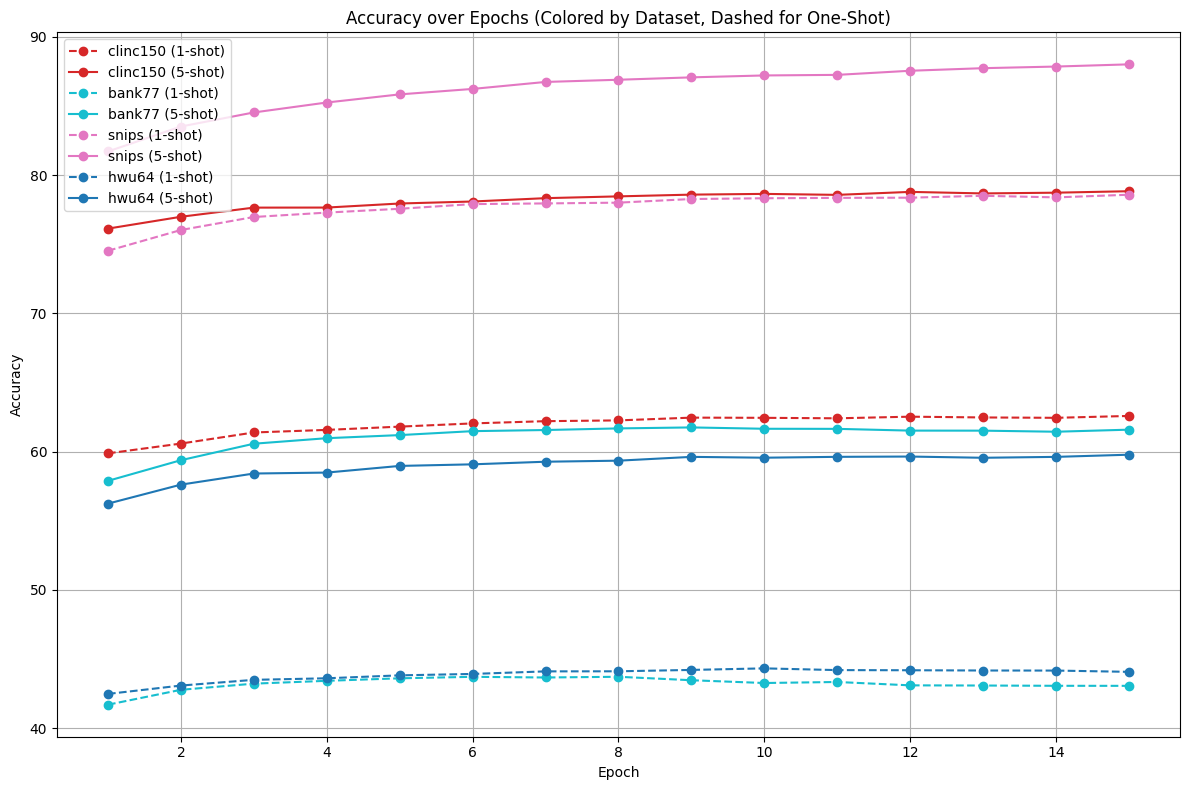

In [4]:
# Перестроим график с разными цветами для каждого датасета,
# и разными стилями линий для 1-shot (пунктир) и 5-shot (сплошная)

import matplotlib.cm as cm
import numpy as np

# Создаем цветовую карту
color_map = cm.get_cmap('tab10', len(set([d["dataset"] for d in data])))
dataset_colors = {dataset: color_map(i) for i, dataset in enumerate(set([d["dataset"] for d in data]))}

# Стили линий
line_styles = {1: 'dashed', 5: 'solid'}

# Построение графика
plt.figure(figsize=(12, 8))

if not df.empty:
    for dataset in df['dataset'].unique():
        color = dataset_colors[dataset]
        for shot in df['shot'].unique():
            subset = df[(df['dataset'] == dataset) & (df['shot'] == shot)]
            if not subset.empty:
                linestyle = line_styles.get(shot, 'solid')
                label = f"{dataset} ({shot}-shot)"
                plt.plot(subset['epoch'], subset['accuracy'], marker='o',
                         linestyle=linestyle, color=color, label=label)

    plt.title("Accuracy over Epochs (Colored by Dataset, Dashed for One-Shot)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных для отображения графика.")


## ubuntu

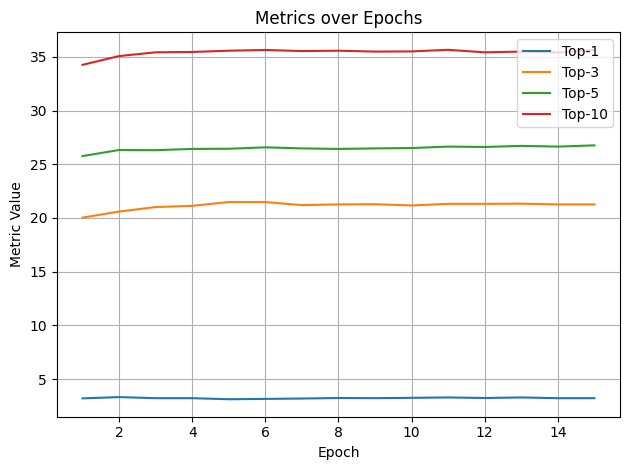

In [5]:
import os
import matplotlib.pyplot as plt

# Define the root directory where the folders are
root_dir = "/home/coder/project/metrics_contrastive_baseline/rs_ubuntu_sim/contrastive_bertbasecontrastive.HardNeg.epoch15.bertbase.dse_training.tsv.lr3e-06.lrscale100.bs1024.tmp0.05.decay1.seed1.turn1"

# Each folder (1, 2, ..., 15) should have a 'results.txt' file
epoch_metrics = []

# Read results.txt from each numbered folder
for epoch in range(1, 16):
    file_path = os.path.join(root_dir, str(epoch), "results.txt")
    try:
        with open(file_path, 'r') as file:
            line = file.readline().strip()
            metrics = list(map(float, line.split("|")))
            epoch_metrics.append(metrics)
    except FileNotFoundError:
        # If the file doesn't exist, append None to keep indexing consistent
        epoch_metrics.append([None, None, None, None])

# Transpose the list to separate metrics for 1, 3, 5, 10
metric_1, metric_3, metric_5, metric_10 = zip(*epoch_metrics)

# Plotting
epochs = list(range(1, 16))
plt.plot(epochs, metric_1, label='Top-1')
plt.plot(epochs, metric_3, label='Top-3')
plt.plot(epochs, metric_5, label='Top-5')
plt.plot(epochs, metric_10, label='Top-10')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Metrics over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## amason

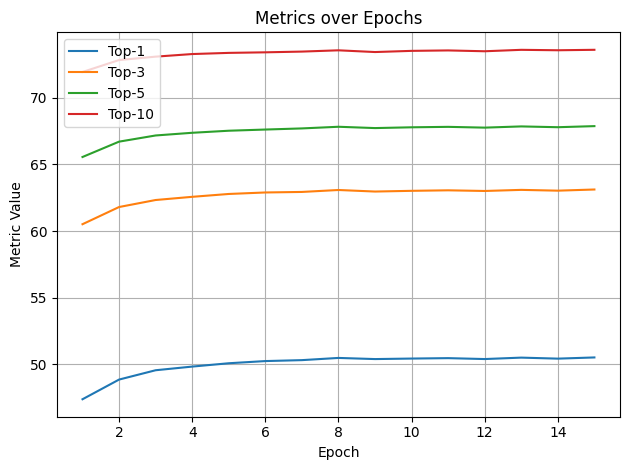

In [6]:
import os
import matplotlib.pyplot as plt

# Define the root directory where the folders are
root_dir = "/home/coder/project/metrics_contrastive_baseline/rs_sim/contrastive_bertbasecontrastive.HardNeg.epoch15.bertbase.dse_training.tsv.lr3e-06.lrscale100.bs1024.tmp0.05.decay1.seed1.turn1"

# Each folder (1, 2, ..., 15) should have a 'results.txt' file
epoch_metrics = []

# Read results.txt from each numbered folder
for epoch in range(1, 16):
    file_path = os.path.join(root_dir, str(epoch), "results.txt")
    try:
        with open(file_path, 'r') as file:
            line = file.readline().strip()
            metrics = list(map(float, line.split("|")))
            epoch_metrics.append(metrics)
    except FileNotFoundError:
        # If the file doesn't exist, append None to keep indexing consistent
        epoch_metrics.append([None, None, None, None])

# Transpose the list to separate metrics for 1, 3, 5, 10
metric_1, metric_3, metric_5, metric_10 = zip(*epoch_metrics)

# Plotting
epochs = list(range(1, 16))
plt.plot(epochs, metric_1, label='Top-1')
plt.plot(epochs, metric_3, label='Top-3')
plt.plot(epochs, metric_5, label='Top-5')
plt.plot(epochs, metric_10, label='Top-10')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Metrics over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## oos

In [10]:
df

,folder,shot_type,threshold,acc,ins_acc,oos_acc,oos_recall
0,1,1-shot,0.0,0.571018,0.578267,0.842891,0.5384
1,1,1-shot,1.0,0.498655,0.408333,0.615655,0.9051
2,1,5-shot,2.0,0.318855,0.170200,0.339273,0.9878
3,1,5-shot,0.0,0.710418,0.727867,0.872418,0.6319
4,1,5-shot,1.0,0.575400,0.496244,0.644273,0.9316
...,...,...,...,...,...,...,...
85,15,1-shot,1.0,0.507236,0.415044,0.606073,0.9221
86,15,5-shot,2.0,0.320618,0.171644,0.337982,0.9910
87,15,5-shot,0.0,0.733291,0.757444,0.873509,0.6246
88,15,5-shot,1.0,0.584036,0.503244,0.640673,0.9476


/home/coder/tmp/ipykernel_30868/828085223.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(thresholds_unique))


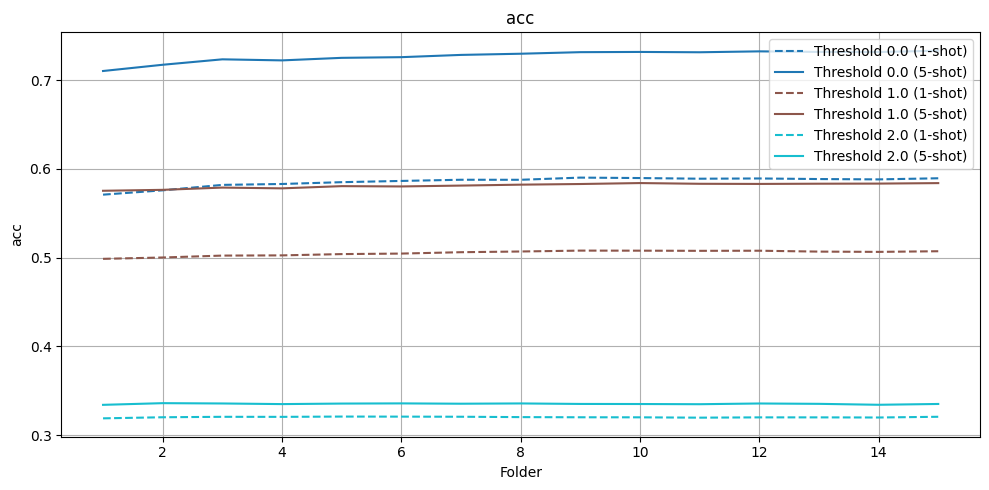

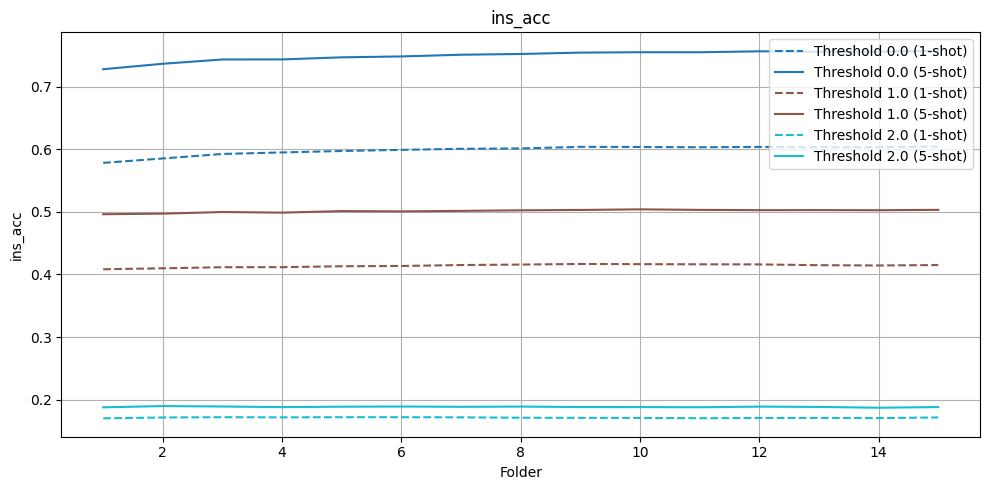

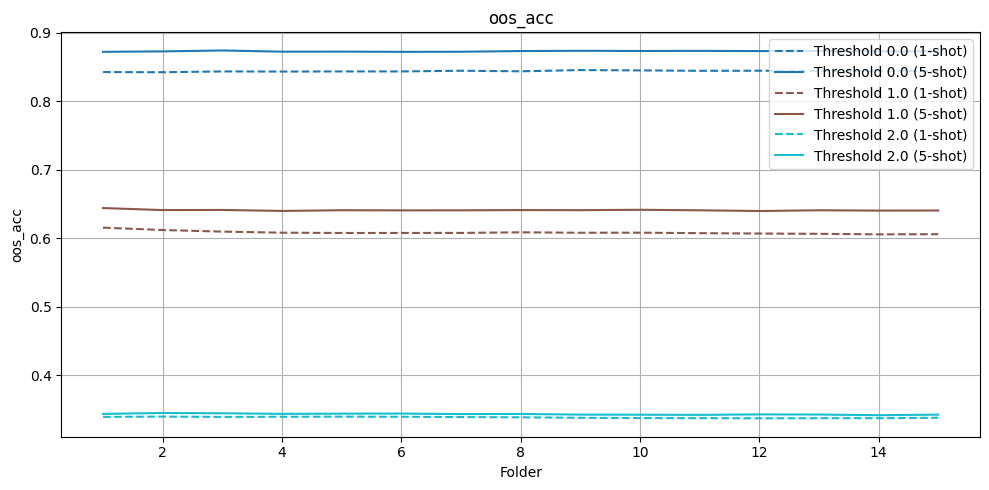

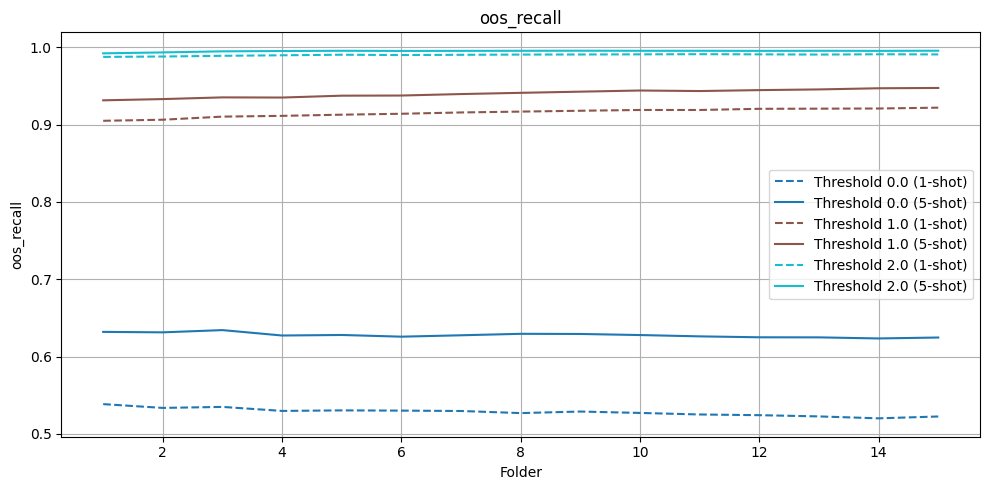

In [19]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# Укажи путь до папки
base_path = "/home/coder/project/metrics_contrastive_baseline/oos_sim/contrastive_bertbasecontrastive.HardNeg.epoch15.bertbase.dse_training.tsv.lr3e-06.lrscale100.bs1024.tmp0.05.decay1.seed1.turn1"

all_data = []

# Чтение results.txt из подпапок
for folder_num in range(1, 16):
    folder_path = os.path.join(base_path, str(folder_num))
    file_path = os.path.join(folder_path, "results.txt")

    if os.path.exists(file_path):
        with open(file_path, "r") as f:
            lines = f.read().strip().split("\n")
            for i, line in enumerate(lines):
                parts = line.strip().split("|")
                if len(parts) != 5:
                    continue  # пропускаем строки с неверным количеством элементов
                threshold, acc, ins_acc, oos_acc, oos_recall = map(float, parts)
                shot_type = "1-shot" if i < 6 else "5-shot"
                all_data.append([folder_num, shot_type, threshold, acc, ins_acc, oos_acc, oos_recall])

# Построение графиков
df = pd.DataFrame(all_data, columns=["folder", "shot_type", "threshold", "acc", "ins_acc", "oos_acc", "oos_recall"])
metrics = ["acc", "ins_acc", "oos_acc", "oos_recall"]
thresholds = df["threshold"].unique()


thresholds_unique = sorted(df["threshold"].unique())
colors = cm.get_cmap("tab10", len(thresholds_unique))
threshold_color_map = {t: colors(i) for i, t in enumerate(thresholds_unique)}

for metric in metrics:
    plt.figure(figsize=(10, 5))
    for t in thresholds:
        for shot in ["1-shot", "5-shot"]:
            subset = df[(df["threshold"] == t) & (df["shot_type"] == shot)]
            if subset.empty:
                continue
            linestyle = "--" if shot == "1-shot" else "-"
            color = threshold_color_map[t]
            label = f"Threshold {t} ({shot})"
            plt.plot(subset["folder"], subset[metric], linestyle=linestyle, color=color, label=label)
    plt.title(metric)
    plt.xlabel("Folder")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
